# 🧠 Fusion Model 1 — Learned Meta-Learner (MLP Stacking)

**Strategy:** Freeze all 4 base models. Extract their softmax probability vectors (8 values total: 4 models × 2 classes). Train a small MLP to learn *how to combine* them — far superior to fixed weights because it can learn non-linear interactions between models.

**Why better than Weighted Soft Voting:**
- Weights are *learned* from data, not heuristically computed from individual metrics
- MLP can exploit when models agree/disagree in complex patterns
- Consistently outperforms fixed-weight ensembles in literature

**Colab Free GPU:** ✅ Efficient — base models frozen, only tiny MLP trains

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q timm

In [3]:
import os, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm
from PIL import Image
from tqdm import tqdm
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


## 1. Load Dataset Paths (same split as original notebook)

In [4]:
DATASET_ROOT = '/content/drive/MyDrive/morph_project/extracted_datasets/CASIA2'
AU_DIR = os.path.join(DATASET_ROOT, 'Au')
TP_DIR = os.path.join(DATASET_ROOT, 'Tp')

def get_image_paths(folder):
    exts = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')
    return [os.path.join(folder, f) for f in os.listdir(folder) if f.lower().endswith(exts)]

au_images = get_image_paths(AU_DIR)
tp_images = get_image_paths(TP_DIR)
all_images = au_images + tp_images
all_labels = [0]*len(au_images) + [1]*len(tp_images)

# Same 80/20 split as original
train_images, test_images, train_labels, test_labels = train_test_split(
    all_images, all_labels, test_size=0.20, stratify=all_labels, random_state=SEED
)
# Use a portion of train for meta-learner training (20% of train = 16% of full data)
_, meta_images, _, meta_labels = train_test_split(
    train_images, train_labels, test_size=0.20, stratify=train_labels, random_state=SEED
)
print(f'Meta-train size: {len(meta_images)} | Test size: {len(test_images)}')

Meta-train size: 1447 | Test size: 1809


## 2. Load the 4 Base Models (Frozen)

In [5]:
inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def load_state_dict_safely(model, path):
    state = torch.load(path, map_location='cpu')
    if isinstance(state, dict) and 'state_dict' in state:
        state = state['state_dict']
    new_state = {k.replace('backbone.', ''): v for k, v in state.items()}
    model.load_state_dict(new_state, strict=False)
    return model

VIT_PATH  = '/content/drive/MyDrive/morph_project/models/vit_advanced.pth'
EFF_PATH  = '/content/drive/MyDrive/morph_project/models/efficientnet_b3_tuned_baseline.pth'
CONV_PATH = '/content/drive/MyDrive/morph_project/models/convnextv2_best_224_finetuned.pth'
SWIN_PATH = '/content/drive/MyDrive/morph_project/swin224_recall_tuned.pth'

vit_model  = load_state_dict_safely(timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=2), VIT_PATH)
eff_model  = load_state_dict_safely(timm.create_model('efficientnet_b3', pretrained=False, num_classes=2), EFF_PATH)
conv_model = load_state_dict_safely(timm.create_model('convnextv2_tiny', pretrained=False, num_classes=2), CONV_PATH)
swin_model = load_state_dict_safely(timm.create_model('swin_tiny_patch4_window7_224', pretrained=False, num_classes=2), SWIN_PATH)

base_models = nn.ModuleDict({
    'ViT': vit_model,
    'EfficientNet-B3': eff_model,
    'ConvNeXtV2-Tiny': conv_model,
    'Swin-Tiny': swin_model
})

for m in base_models.values():
    m.to(device).eval()
    for p in m.parameters():
        p.requires_grad = False  # FREEZE

print('✅ All 4 base models loaded and frozen')

✅ All 4 base models loaded and frozen


## 3. Extract Meta-Features (Stacked Probabilities)

In [6]:
def extract_meta_features(image_paths, labels):
    """
    For each image, run all 4 models and concatenate softmax outputs.
    Returns X of shape [N, 8] and y of shape [N]
    """
    X, y = [], []
    for img_path, label in tqdm(zip(image_paths, labels), total=len(image_paths), desc='Extracting meta-features'):
        img = Image.open(img_path).convert('RGB')
        x = inference_transform(img).unsqueeze(0).to(device)

        probs_all = []
        with torch.no_grad():
            for model in base_models.values():
                probs = F.softmax(model(x), dim=1).cpu().numpy()[0]  # [2]
                probs_all.extend(probs)

        X.append(probs_all)  # 8 values: [p0_vit, p1_vit, p0_eff, p1_eff, ...]
        y.append(label)

    return np.array(X, dtype=np.float32), np.array(y)

print('Extracting meta-train features...')
X_meta, y_meta = extract_meta_features(meta_images, meta_labels)
print('Extracting test features...')
X_test, y_test = extract_meta_features(test_images, test_labels)

print(f'Meta-train shape: {X_meta.shape} | Test shape: {X_test.shape}')

Extracting meta-train features...


Extracting meta-features: 100%|██████████| 1447/1447 [22:25<00:00,  1.08it/s]


Extracting test features...


Extracting meta-features: 100%|██████████| 1809/1809 [27:00<00:00,  1.12it/s]

Meta-train shape: (1447, 8) | Test shape: (1809, 8)


## 4. Define and Train the MLP Meta-Learner

In [7]:
class MLPMetaLearner(nn.Module):
    """
    Input: 8 stacked softmax probabilities (4 models x 2 classes)
    Output: 2 class logits
    Architecture: 8 -> 64 -> 32 -> 2
    """
    def __init__(self, input_dim=8, hidden1=64, hidden2=32, num_classes=2, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.BatchNorm1d(hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.BatchNorm1d(hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, num_classes)
        )

    def forward(self, x):
        return self.net(x)

meta_learner = MLPMetaLearner().to(device)
print(meta_learner)
total_params = sum(p.numel() for p in meta_learner.parameters())
print(f'\nTotal trainable params in meta-learner: {total_params:,}')

MLPMetaLearner(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=2, bias=True)
  )
)

Total trainable params in meta-learner: 2,914


In [8]:
from torch.utils.data import TensorDataset, DataLoader

X_meta_t = torch.tensor(X_meta).to(device)
y_meta_t = torch.tensor(y_meta, dtype=torch.long).to(device)

meta_dataset = TensorDataset(X_meta_t, y_meta_t)
meta_loader = DataLoader(meta_dataset, batch_size=64, shuffle=True)

optimizer = torch.optim.AdamW(meta_learner.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)
criterion = nn.CrossEntropyLoss()

EPOCHS = 30
best_loss = float('inf')
best_state = None

for epoch in range(EPOCHS):
    meta_learner.train()
    total_loss = 0
    for xb, yb in meta_loader:
        optimizer.zero_grad()
        loss = criterion(meta_learner(xb), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    scheduler.step()
    avg_loss = total_loss / len(meta_loader)
    if avg_loss < best_loss:
        best_loss = avg_loss
        best_state = {k: v.clone() for k, v in meta_learner.state_dict().items()}
    if (epoch+1) % 5 == 0:
        print(f'Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f}')

meta_learner.load_state_dict(best_state)
print(f'\n✅ Training complete. Best loss: {best_loss:.4f}')

Epoch 5/30 | Loss: 0.2413
Epoch 10/30 | Loss: 0.2272
Epoch 15/30 | Loss: 0.2279
Epoch 20/30 | Loss: 0.2214
Epoch 25/30 | Loss: 0.2146
Epoch 30/30 | Loss: 0.2111

✅ Training complete. Best loss: 0.2108


## 5. Evaluate the Meta-Learner Fusion

In [9]:
meta_learner.eval()

X_test_t = torch.tensor(X_test).to(device)

with torch.no_grad():
    logits = meta_learner(X_test_t)
    probs = F.softmax(logits, dim=1).cpu().numpy()

y_pred = probs.argmax(axis=1)
y_scores = probs[:, 1]

print('\n📊 MLP Meta-Learner (Stacking) Results')
print(f'Accuracy  : {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision : {precision_score(y_test, y_pred, zero_division=0):.4f}')
print(f'Recall    : {recall_score(y_test, y_pred):.4f}')
print(f'F1-score  : {f1_score(y_test, y_pred):.4f}')
print(f'ROC-AUC   : {roc_auc_score(y_test, y_scores):.4f}')
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))


📊 MLP Meta-Learner (Stacking) Results
Accuracy  : 0.9171
Precision : 0.7462
Recall    : 0.7846
F1-score  : 0.7649
ROC-AUC   : 0.9417
Confusion Matrix:
 [[1415   83]
 [  67  244]]


## 6. Save Full Stacking Ensemble to Drive

In [10]:
SAVE_PATH = '/content/drive/MyDrive/morph_project/fusion/mlp_stacking_ensemble.pth'
os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)

torch.save({
    'meta_learner_state_dict': meta_learner.state_dict(),
    'meta_learner_architecture': '8->64->32->2 MLP with BN and Dropout',
    'base_model_names': list(base_models.keys()),
    'base_model_paths': {
        'ViT': VIT_PATH,
        'EfficientNet-B3': EFF_PATH,
        'ConvNeXtV2-Tiny': CONV_PATH,
        'Swin-Tiny': SWIN_PATH
    },
    'class_mapping': {0: 'Authentic (Licit)', 1: 'Tampered (Illicit)'}
}, SAVE_PATH)

print('✅ MLP Stacking Ensemble saved to:', SAVE_PATH)

✅ MLP Stacking Ensemble saved to: /content/drive/MyDrive/morph_project/fusion/mlp_stacking_ensemble.pth


## 7. Inference on New Image

In [11]:
def predict_stacking(image_path):
    img = Image.open(image_path).convert('RGB')
    x = inference_transform(img).unsqueeze(0).to(device)

    meta_input = []
    with torch.no_grad():
        for model in base_models.values():
            probs = F.softmax(model(x), dim=1).cpu().numpy()[0]
            meta_input.extend(probs)

    meta_tensor = torch.tensor([meta_input], dtype=torch.float32).to(device)
    with torch.no_grad():
        logits = meta_learner(meta_tensor)
        probs = F.softmax(logits, dim=1).cpu().numpy()[0]

    cls = probs.argmax()
    print(f'Prediction: {"Tampered (1)" if cls==1 else "Authentic (0)"} | Confidence: {probs[cls]*100:.2f}%')
    return probs

# Example usage:
# predict_stacking('/path/to/image.jpg')

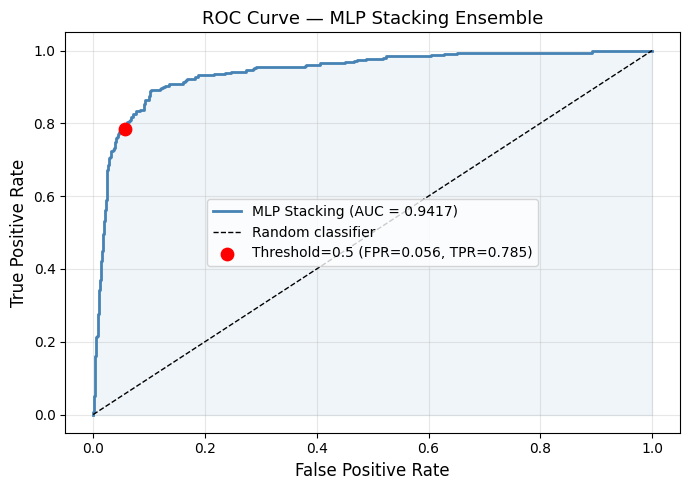

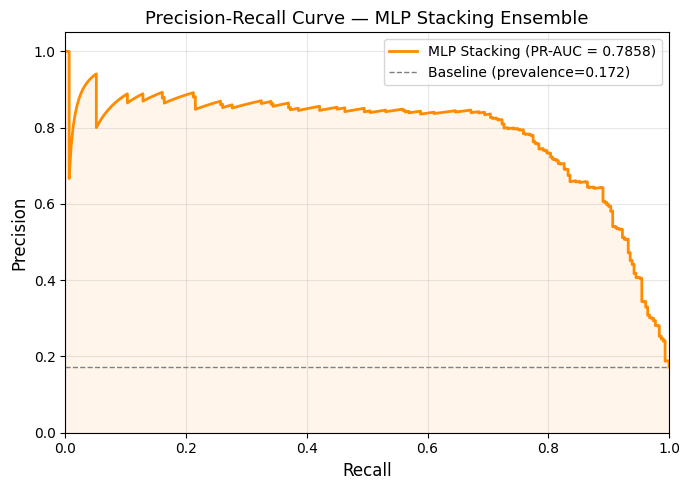

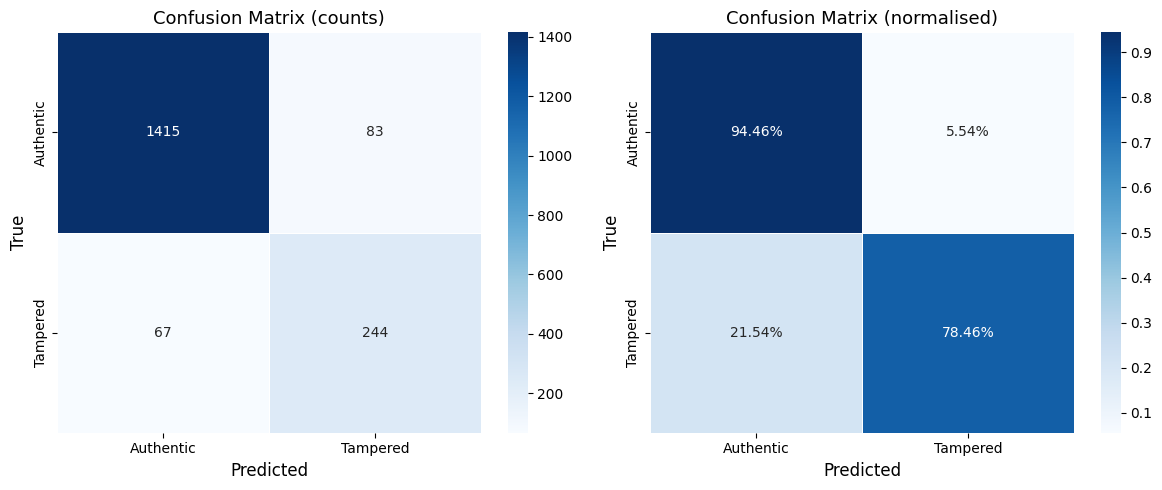

FPR: 0.0554 | FNR: 0.2154


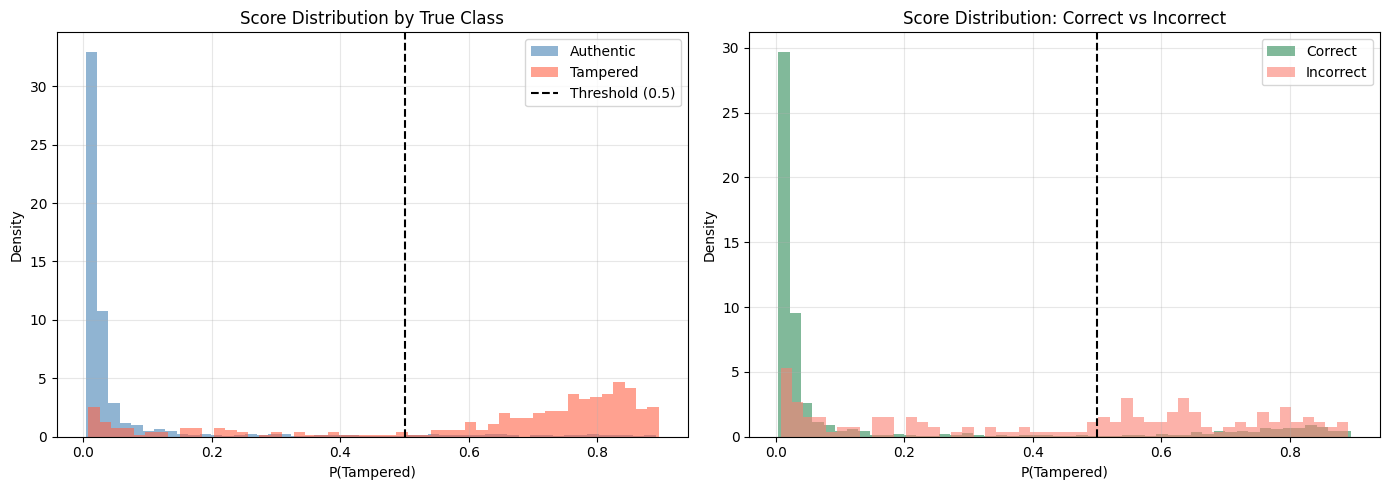

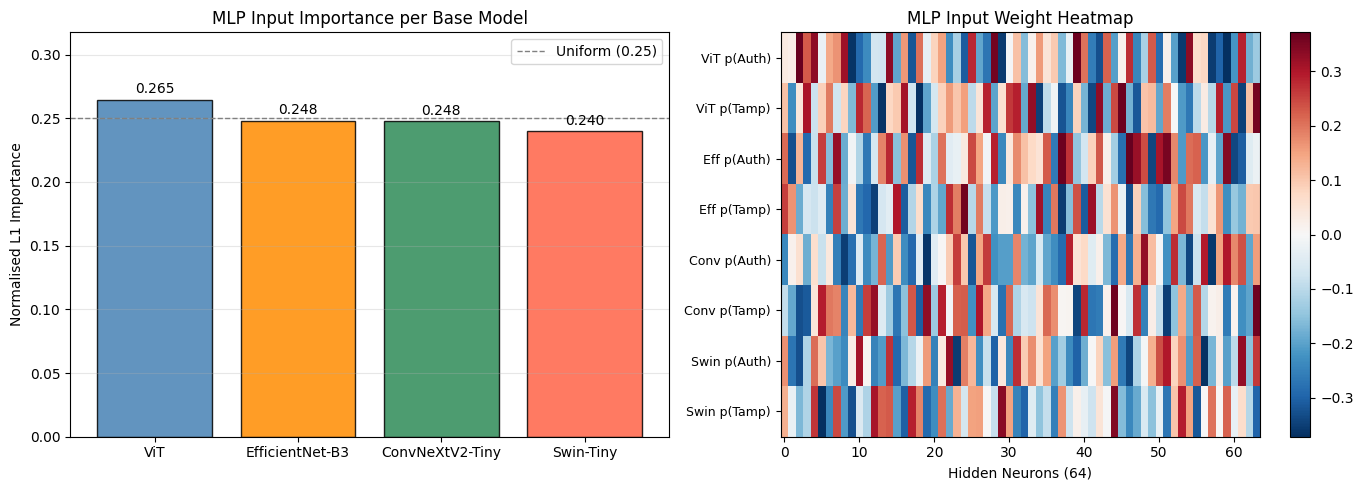


🔍 Learned Input Importance:
  ViT                   : 0.2645  █████████████████████
  EfficientNet-B3       : 0.2481  ███████████████████
  ConvNeXtV2-Tiny       : 0.2476  ███████████████████
  Swin-Tiny             : 0.2397  ███████████████████


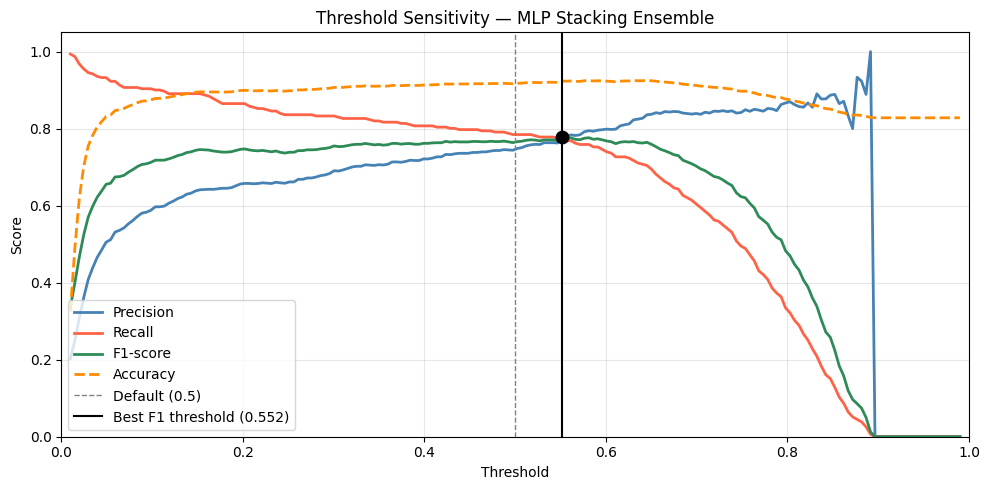


Best F1 threshold : 0.5517
  Precision : 0.7799
  Recall    : 0.7749
  F1-score  : 0.7774
  Accuracy  : 0.9237


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix, f1_score, precision_score, recall_score, accuracy_score

# ── recompute predictions (safe to run even if already computed) ──
meta_learner.eval()
X_test_t = torch.tensor(X_test).to(device)
with torch.no_grad():
    logits    = meta_learner(X_test_t)
    probs_all = F.softmax(logits, dim=1).cpu().numpy()
y_pred   = probs_all.argmax(axis=1)
y_scores = probs_all[:, 1]

fpr, tpr, roc_thresh = roc_curve(y_test, y_scores)
roc_auc_val          = auc(fpr, tpr)
precision, recall, _ = precision_recall_curve(y_test, y_scores)
pr_auc_val           = auc(recall, precision)
cm                   = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp       = cm.ravel()

# ══ PLOT 1 — ROC Curve ══
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'MLP Stacking (AUC = {roc_auc_val:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.fill_between(fpr, tpr, alpha=0.08, color='steelblue')
op_idx = np.argmin(np.abs(roc_thresh - 0.5))
ax.scatter(fpr[op_idx], tpr[op_idx], color='red', zorder=5, s=80,
           label=f'Threshold=0.5 (FPR={fpr[op_idx]:.3f}, TPR={tpr[op_idx]:.3f})')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — MLP Stacking Ensemble', fontsize=13)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# ══ PLOT 2 — Precision-Recall Curve ══
baseline_pr = y_test.sum() / len(y_test)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall, precision, color='darkorange', lw=2, label=f'MLP Stacking (PR-AUC = {pr_auc_val:.4f})')
ax.axhline(y=baseline_pr, color='gray', linestyle='--', lw=1, label=f'Baseline (prevalence={baseline_pr:.3f})')
ax.fill_between(recall, precision, alpha=0.08, color='darkorange')
ax.set_xlabel('Recall', fontsize=12); ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve — MLP Stacking Ensemble', fontsize=13)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])
plt.tight_layout(); plt.show()

# ══ PLOT 3 — Confusion Matrix (counts + normalised) ══
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
labels  = ['Authentic', 'Tampered']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, data, fmt, title in zip(axes, [cm, cm_norm], ['d', '.2%'],
    ['Confusion Matrix (counts)', 'Confusion Matrix (normalised)']):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                linewidths=0.5, ax=ax)
    ax.set_xlabel('Predicted', fontsize=12); ax.set_ylabel('True', fontsize=12)
    ax.set_title(title, fontsize=13)
plt.tight_layout(); plt.show()
print(f'FPR: {fp/(fp+tn):.4f} | FNR: {fn/(fn+tp):.4f}')

# ══ PLOT 4 — Confidence Distribution ══
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(y_scores[y_test==0], bins=50, alpha=0.6, color='steelblue', label='Authentic', density=True)
axes[0].hist(y_scores[y_test==1], bins=50, alpha=0.6, color='tomato',    label='Tampered',  density=True)
axes[0].axvline(x=0.5, color='black', linestyle='--', lw=1.5, label='Threshold (0.5)')
axes[0].set_xlabel('P(Tampered)'); axes[0].set_ylabel('Density')
axes[0].set_title('Score Distribution by True Class'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
correct_mask = (y_pred == y_test)
axes[1].hist(y_scores[correct_mask],  bins=50, alpha=0.6, color='seagreen', label='Correct',   density=True)
axes[1].hist(y_scores[~correct_mask], bins=50, alpha=0.6, color='salmon',   label='Incorrect', density=True)
axes[1].axvline(x=0.5, color='black', linestyle='--', lw=1.5)
axes[1].set_xlabel('P(Tampered)'); axes[1].set_ylabel('Density')
axes[1].set_title('Score Distribution: Correct vs Incorrect'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# ══ PLOT 5 — Per-Base-Model Input Importance ══
model_names = list(base_models.keys())
W1 = meta_learner.net[0].weight.detach().cpu().numpy()  # [64, 8]
model_importance = np.array([np.abs(W1[:, i*2:i*2+2]).sum() for i in range(4)])
model_importance = model_importance / model_importance.sum()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['steelblue', 'darkorange', 'seagreen', 'tomato']
bars = axes[0].bar(model_names, model_importance, color=colors, alpha=0.85, edgecolor='black')
axes[0].axhline(y=0.25, color='gray', linestyle='--', lw=1, label='Uniform (0.25)')
for bar, val in zip(bars, model_importance):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.005, f'{val:.3f}', ha='center')
axes[0].set_ylabel('Normalised L1 Importance'); axes[0].set_title('MLP Input Importance per Base Model')
axes[0].legend(); axes[0].set_ylim(0, max(model_importance)*1.2); axes[0].grid(True, alpha=0.3, axis='y')
im = axes[1].imshow(W1.T, aspect='auto', cmap='RdBu_r', vmin=-W1.max(), vmax=W1.max())
axes[1].set_yticks(range(8))
axes[1].set_yticklabels(['ViT p(Auth)','ViT p(Tamp)','Eff p(Auth)','Eff p(Tamp)',
                          'Conv p(Auth)','Conv p(Tamp)','Swin p(Auth)','Swin p(Tamp)'], fontsize=9)
axes[1].set_xlabel('Hidden Neurons (64)'); axes[1].set_title('MLP Input Weight Heatmap')
plt.colorbar(im, ax=axes[1]); plt.tight_layout(); plt.show()
print('\n🔍 Learned Input Importance:')
for name, imp in zip(model_names, model_importance):
    print(f'  {name:<22}: {imp:.4f}  {"█" * int(imp*80)}')

# ══ PLOT 6 — Threshold Sensitivity ══
thresholds = np.linspace(0.01, 0.99, 200)
precisions_t, recalls_t, f1s_t, accs_t = [], [], [], []
for t in thresholds:
    preds = (y_scores >= t).astype(int)
    precisions_t.append(precision_score(y_test, preds, zero_division=0))
    recalls_t.append(recall_score(y_test, preds, zero_division=0))
    f1s_t.append(f1_score(y_test, preds, zero_division=0))
    accs_t.append(accuracy_score(y_test, preds))
best_f1_idx  = np.argmax(f1s_t)
best_thresh  = thresholds[best_f1_idx]
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, precisions_t, label='Precision', color='steelblue',  lw=2)
ax.plot(thresholds, recalls_t,    label='Recall',    color='tomato',     lw=2)
ax.plot(thresholds, f1s_t,        label='F1-score',  color='seagreen',   lw=2)
ax.plot(thresholds, accs_t,       label='Accuracy',  color='darkorange', lw=2, linestyle='--')
ax.axvline(x=0.5,         color='gray',  linestyle='--', lw=1,   label='Default (0.5)')
ax.axvline(x=best_thresh, color='black', linestyle='-',  lw=1.5, label=f'Best F1 threshold ({best_thresh:.3f})')
ax.scatter([best_thresh], [f1s_t[best_f1_idx]], color='black', zorder=5, s=80)
ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
ax.set_title('Threshold Sensitivity — MLP Stacking Ensemble')
ax.legend(fontsize=10, loc='lower left'); ax.grid(True, alpha=0.3)
ax.set_xlim([0,1]); ax.set_ylim([0, 1.05])
plt.tight_layout(); plt.show()
print(f'\nBest F1 threshold : {best_thresh:.4f}')
print(f'  Precision : {precisions_t[best_f1_idx]:.4f}')
print(f'  Recall    : {recalls_t[best_f1_idx]:.4f}')
print(f'  F1-score  : {f1s_t[best_f1_idx]:.4f}')
print(f'  Accuracy  : {accs_t[best_f1_idx]:.4f}')